# Phase 3: Modeling
**LendingClub Loan Default Prediction**

Models: Logistic Regression (baseline) → Random Forest → XGBoost  
Evaluation: ROC-AUC, Precision-Recall AUC, F1 (threshold-tuned)  
Explainability: SHAP values + model vs. LendingClub grade comparison

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay,
    f1_score, precision_recall_curve
)
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import shap

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
RANDOM_STATE = 42

DATA_PATH = r'C:\Users\Administrator\Desktop\DataMiningProject\processed_data.csv'

## 1. Load Processed Data

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Target distribution:\n{df['target'].value_counts()}")
print(f"Default rate: {df['target'].mean():.2%}")

X = df.drop(columns=['target'])
y = df['target']

# Drop any object columns that slipped through preprocessing (e.g. disbursement_method)
obj_cols = X.select_dtypes(include='object').columns.tolist()
if obj_cols:
    print(f"\nDropping {len(obj_cols)} un-encoded string column(s): {obj_cols}")
    X = X.drop(columns=obj_cols)

print(f"\nFeatures: {X.shape[1]}")

Loaded: 1,345,310 rows x 133 columns
Target distribution:
target
0    1076751
1     268559
Name: count, dtype: int64
Default rate: 19.96%

Features: 132


## 2. Train / Test Split
Stratified 80/20 split preserves the ~20% default rate in both sets.

In [3]:
# Force every column to numeric — coerces any stray strings (e.g. 'Cash') to NaN
X = X.apply(pd.to_numeric, errors='coerce')

# Fill any NaN introduced by coercion with column medians
X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]:,} rows  |  default rate: {y_train.mean():.2%}")
print(f"Test:  {X_test.shape[0]:,} rows  |  default rate: {y_test.mean():.2%}")
print(f"Features used: {X_train.shape[1]}")

Train: 1,076,248 rows  |  default rate: 19.96%
Test:  269,062 rows  |  default rate: 19.96%
Features used: 132


## 3. Evaluation Helper
Single function to compute and display all metrics consistently across models.

In [4]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, threshold=0.5):
    # Coerce to numeric at the last possible moment — catches any stray strings
    X_tr = X_tr.apply(pd.to_numeric, errors='coerce')
    X_te = X_te.apply(pd.to_numeric, errors='coerce')
    col_medians = X_tr.median()
    X_tr = X_tr.fillna(col_medians)
    X_te = X_te.fillna(col_medians)

    model.fit(X_tr, y_tr)
    proba = model.predict_proba(X_te)[:, 1]
    preds = (proba >= threshold).astype(int)

    roc  = roc_auc_score(y_te, proba)
    pr   = average_precision_score(y_te, proba)
    f1   = f1_score(y_te, preds)

    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  ROC-AUC:          {roc:.4f}")
    print(f"  PR-AUC:           {pr:.4f}")
    print(f"  F1 (t={threshold:.2f}):     {f1:.4f}")
    print(classification_report(y_te, preds, target_names=['Fully Paid', 'Charged Off']))

    return {'name': name, 'model': model, 'proba': proba,
            'roc': roc, 'pr': pr, 'f1': f1}

## 4. Logistic Regression — Baseline
`class_weight='balanced'` handles the 80/20 imbalance without resampling.

In [5]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        solver='saga',
        C=0.1,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

lr_results = evaluate_model('Logistic Regression (balanced)', lr_pipe,
                             X_train, y_train, X_test, y_test)

  Logistic Regression (balanced)
  ROC-AUC:          0.7186
  PR-AUC:           0.3828
  F1 (t=0.50):     0.4359
              precision    recall  f1-score   support

  Fully Paid       0.88      0.67      0.76    215350
 Charged Off       0.33      0.65      0.44     53712

    accuracy                           0.66    269062
   macro avg       0.61      0.66      0.60    269062
weighted avg       0.77      0.66      0.70    269062



### 4a. Logistic Regression — 5-Fold Cross-Validation (ROC-AUC)

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_cv = cross_val_score(lr_pipe, X_train, y_train,
                        cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"LR CV ROC-AUC: {lr_cv.mean():.4f} ± {lr_cv.std():.4f}  |  folds: {lr_cv.round(4)}")

LR CV ROC-AUC: 0.7178 ± 0.0014  |  folds: [0.7169 0.7203 0.7181 0.7164 0.7172]


## 5. Random Forest
`class_weight='balanced_subsample'` re-balances within each bootstrap sample.

In [7]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=50,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_results = evaluate_model('Random Forest', rf_model,
                             X_train, y_train, X_test, y_test)

  Random Forest
  ROC-AUC:          0.7175
  PR-AUC:           0.3859
  F1 (t=0.50):     0.4326
              precision    recall  f1-score   support

  Fully Paid       0.89      0.64      0.74    215350
 Charged Off       0.32      0.67      0.43     53712

    accuracy                           0.65    269062
   macro avg       0.60      0.66      0.59    269062
weighted avg       0.77      0.65      0.68    269062



In [8]:
rf_cv = cross_val_score(rf_model, X_train, y_train,
                        cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"RF CV ROC-AUC: {rf_cv.mean():.4f} ± {rf_cv.std():.4f}  |  folds: {rf_cv.round(4)}")

RF CV ROC-AUC: 0.7172 ± 0.0013  |  folds: [0.7162 0.7195 0.7178 0.7157 0.7171]


## 6. XGBoost
`scale_pos_weight = neg/pos` is XGBoost's native imbalance correction — equivalent to `class_weight='balanced'` for tree boosters.

In [9]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos = neg / pos
print(f"scale_pos_weight = {scale_pos:.2f}  (neg={neg:,}  pos={pos:,})")

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric='auc',
    use_label_encoder=False,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method='hist'
)

xgb_results = evaluate_model('XGBoost', xgb_model,
                              X_train, y_train, X_test, y_test)

scale_pos_weight = 4.01  (neg=861,401  pos=214,847)
  XGBoost
  ROC-AUC:          0.7342
  PR-AUC:           0.4095
  F1 (t=0.50):     0.4461
              precision    recall  f1-score   support

  Fully Paid       0.89      0.66      0.76    215350
 Charged Off       0.33      0.68      0.45     53712

    accuracy                           0.66    269062
   macro avg       0.61      0.67      0.60    269062
weighted avg       0.78      0.66      0.70    269062



In [10]:
xgb_cv = cross_val_score(xgb_model, X_train, y_train,
                         cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"XGB CV ROC-AUC: {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}  |  folds: {xgb_cv.round(4)}")

XGB CV ROC-AUC: 0.7333 ± 0.0009  |  folds: [0.7326 0.7348 0.7334 0.7321 0.7334]


## 6b. XGBoost with SMOTE
SMOTE (Synthetic Minority Over-sampling Technique) creates synthetic minority-class samples instead of relying on class weights.
We compare it directly against XGBoost with scale_pos_weight.

In [14]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'Original train set : {X_train.shape[0]:,} rows  |  default rate: {y_train.mean():.2%}')
print(f'SMOTE resampled    : {X_train_sm.shape[0]:,} rows  |  default rate: {y_train_sm.mean():.2%}')

xgb_smote = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',
    use_label_encoder=False,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method='hist'
)

smote_results = evaluate_model('XGBoost + SMOTE', xgb_smote,
                               X_train_sm, y_train_sm, X_test, y_test)

xgb_roc   = xgb_results['roc']
smote_roc = smote_results['roc']
print('SMOTE vs class_weight comparison:')
print(f'  XGBoost (scale_pos_weight) ROC-AUC: {xgb_roc:.4f}')
print(f'  XGBoost + SMOTE            ROC-AUC: {smote_roc:.4f}')

Original train set : 1,076,248 rows  |  default rate: 19.96%
SMOTE resampled    : 1,722,802 rows  |  default rate: 50.00%
  XGBoost + SMOTE
  ROC-AUC:          0.7314
  PR-AUC:           0.4044
  F1 (t=0.50):     0.1701
              precision    recall  f1-score   support

  Fully Paid       0.81      0.98      0.89    215350
 Charged Off       0.58      0.10      0.17     53712

    accuracy                           0.81    269062
   macro avg       0.70      0.54      0.53    269062
weighted avg       0.77      0.81      0.75    269062

SMOTE vs class_weight comparison:
  XGBoost (scale_pos_weight) ROC-AUC: 0.7342
  XGBoost + SMOTE            ROC-AUC: 0.7314


## 7. ROC & Precision-Recall Curves — All Models

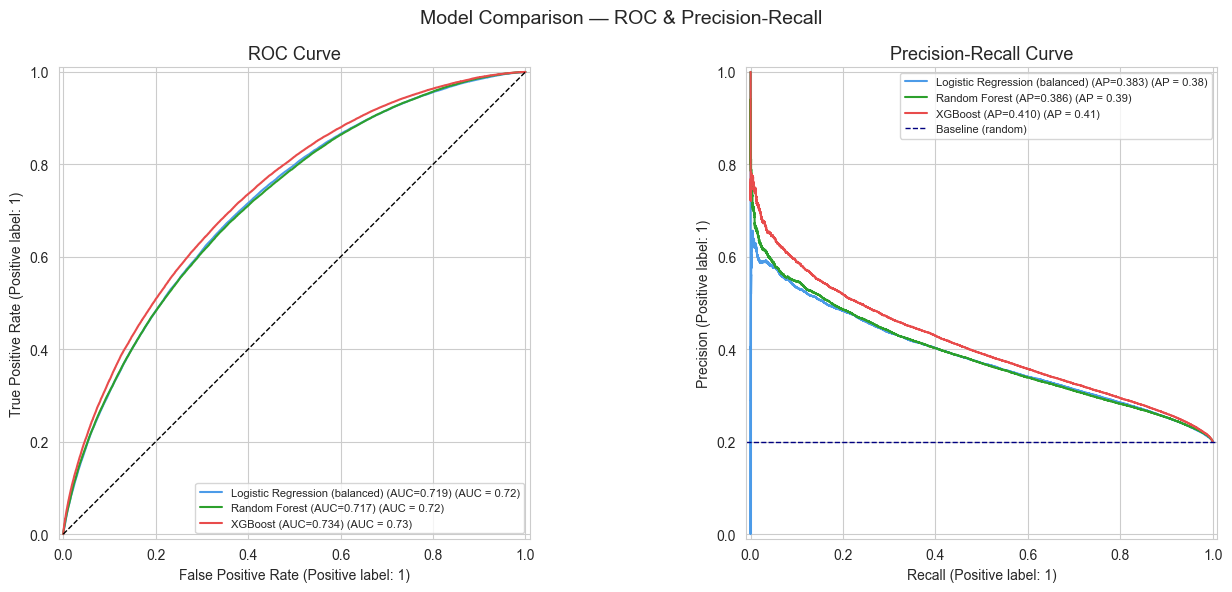

In [15]:
results = [lr_results, rf_results, xgb_results]
colors  = ['#4C9BE8', '#2CA02C', '#E84C4C']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for res, color in zip(results, colors):
    RocCurveDisplay.from_predictions(
        y_test, res['proba'],
        name=f"{res['name']} (AUC={res['roc']:.3f})",
        color=color, ax=axes[0]
    )
    PrecisionRecallDisplay.from_predictions(
        y_test, res['proba'],
        name=f"{res['name']} (AP={res['pr']:.3f})",
        color=color, ax=axes[1]
    )

axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_title('ROC Curve', fontsize=13)
axes[1].axhline(y_test.mean(), color='navy', linestyle='--', lw=1, label='Baseline (random)')
axes[1].set_title('Precision-Recall Curve', fontsize=13)

for ax in axes:
    ax.legend(fontsize=8)

plt.suptitle('Model Comparison — ROC & Precision-Recall', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Threshold Optimization — XGBoost
Default threshold of 0.5 is suboptimal on imbalanced data. Find the threshold that maximises F1.

Best F1 threshold: 0.539
F1 at best threshold: 0.4485
Precision: 0.3548  |  Recall: 0.6092


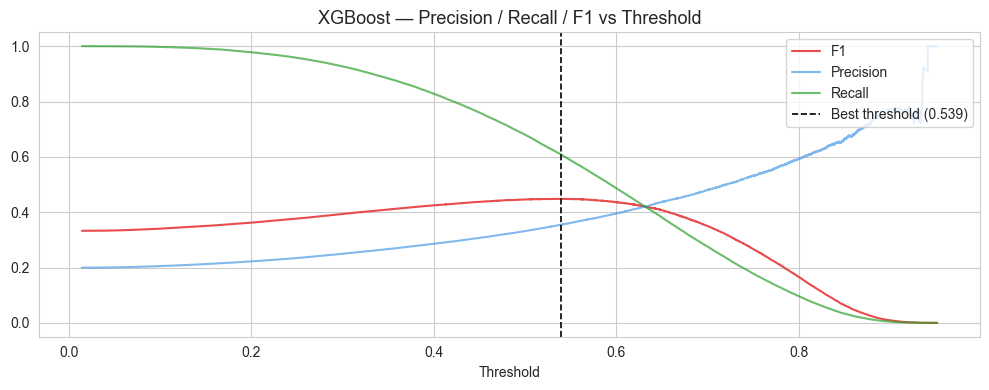


XGBoost at optimal threshold:
              precision    recall  f1-score   support

  Fully Paid       0.88      0.72      0.79    215350
 Charged Off       0.35      0.61      0.45     53712

    accuracy                           0.70    269062
   macro avg       0.62      0.67      0.62    269062
weighted avg       0.78      0.70      0.73    269062



In [16]:
precisions, recalls, thresholds = precision_recall_curve(y_test, xgb_results['proba'])
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx  = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]

print(f"Best F1 threshold: {best_thresh:.3f}")
print(f"F1 at best threshold: {f1_scores[best_idx]:.4f}")
print(f"Precision: {precisions[best_idx]:.4f}  |  Recall: {recalls[best_idx]:.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, f1_scores[:-1], label='F1', color='#E84C4C')
ax.plot(thresholds, precisions[:-1], label='Precision', color='#4C9BE8', alpha=0.7)
ax.plot(thresholds, recalls[:-1], label='Recall', color='#2CA02C', alpha=0.7)
ax.axvline(best_thresh, color='black', linestyle='--', lw=1.2, label=f'Best threshold ({best_thresh:.3f})')
ax.set_xlabel('Threshold')
ax.set_title('XGBoost — Precision / Recall / F1 vs Threshold', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

# Re-evaluate XGBoost at optimal threshold
print("\nXGBoost at optimal threshold:")
xgb_preds_opt = (xgb_results['proba'] >= best_thresh).astype(int)
print(classification_report(y_test, xgb_preds_opt,
                             target_names=['Fully Paid', 'Charged Off']))

## 9. Confusion Matrix — XGBoost (Optimal Threshold)

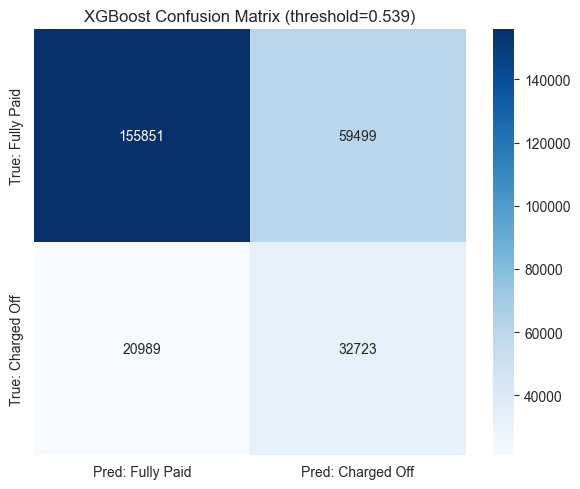

In [17]:
cm = confusion_matrix(y_test, xgb_preds_opt)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Fully Paid', 'Pred: Charged Off'],
            yticklabels=['True: Fully Paid', 'True: Charged Off'],
            ax=ax)
ax.set_title(f'XGBoost Confusion Matrix (threshold={best_thresh:.3f})', fontsize=12)
plt.tight_layout()
plt.show()

## 10. Summary Table — All Models

In [19]:
summary = pd.DataFrame([
    {
        'Model': r['name'],
        'ROC-AUC': round(r['roc'], 4),
        'PR-AUC':  round(r['pr'],  4),
        'F1 (t=0.5)': round(r['f1'], 4),
    }
    for r in results
])

summary.loc[len(summary)] = {
    'Model': 'XGBoost (optimal threshold)',
    'ROC-AUC': round(xgb_results['roc'], 4),
    'PR-AUC':  round(xgb_results['pr'],  4),
    'F1 (t=0.5)': round(f1_score(y_test, xgb_preds_opt), 4),
}

summary = summary.set_index('Model')
print(summary.to_string())

                                ROC-AUC  PR-AUC  F1 (t=0.5)
Model                                                      
Logistic Regression (balanced)   0.7186  0.3828      0.4359
Random Forest                    0.7175  0.3859      0.4326
XGBoost                          0.7342  0.4095      0.4461
XGBoost (optimal threshold)      0.7342  0.4095      0.4485


## 11. SHAP Explainability — XGBoost
SHAP (SHapley Additive exPlanations) reveals which features drive predictions and in which direction.

In [20]:
# Use a 5k sample of the test set for speed
shap_sample = X_test.sample(min(5000, len(X_test)), random_state=RANDOM_STATE)

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(shap_sample)

print(f"SHAP values computed for {len(shap_sample):,} samples x {shap_values.shape[1]} features")

SHAP values computed for 5,000 samples x 132 features


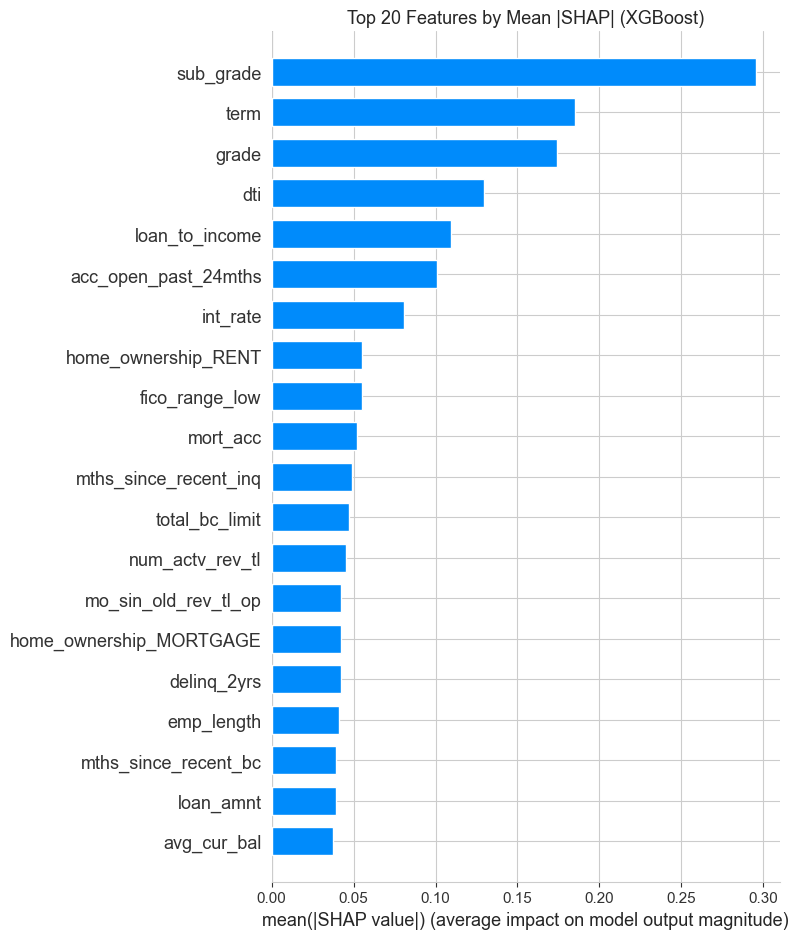

In [21]:
# Global feature importance — mean |SHAP|
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, shap_sample, plot_type='bar',
                  max_display=20, show=False)
plt.title('Top 20 Features by Mean |SHAP| (XGBoost)', fontsize=13)
plt.tight_layout()
plt.show()

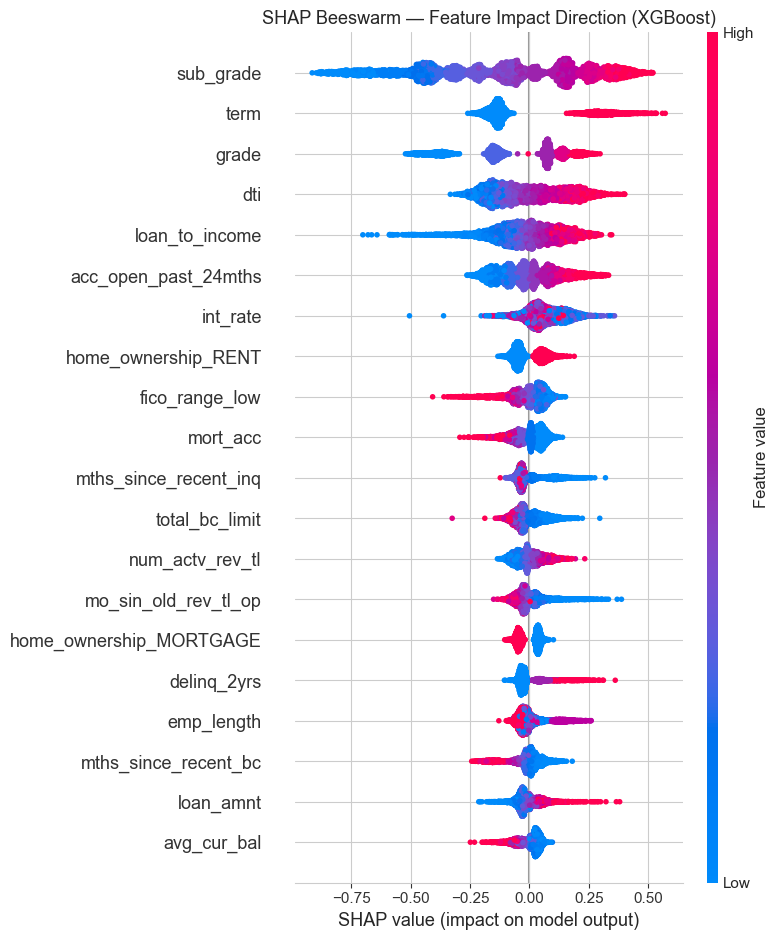

In [22]:
# Beeswarm plot — direction and magnitude per feature
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, shap_sample, max_display=20, show=False)
plt.title('SHAP Beeswarm — Feature Impact Direction (XGBoost)', fontsize=13)
plt.tight_layout()
plt.show()

## 12. Model vs. LendingClub Grade as Risk Signal
The proposal asks whether the model adds value beyond LendingClub's own grade. We compare:
- Grade-only ROC-AUC (treating `grade` 1–7 as a score)
- XGBoost model ROC-AUC
- XGBoost trained **without** grade/sub_grade

In [23]:
# Grade-only baseline: higher grade number = higher risk
grade_auc = roc_auc_score(y_test, X_test['grade'])
print(f"Grade-only ROC-AUC: {grade_auc:.4f}")
print(f"XGBoost ROC-AUC:    {xgb_results['roc']:.4f}")
print(f"Lift over grade:    {xgb_results['roc'] - grade_auc:+.4f}")

Grade-only ROC-AUC: 0.6801
XGBoost ROC-AUC:    0.7342
Lift over grade:    +0.0541


In [24]:
# XGBoost trained WITHOUT grade/sub_grade — does other info alone beat grade?
grade_cols = [c for c in X_train.columns if c in ('grade', 'sub_grade')]
X_train_ng = X_train.drop(columns=grade_cols)
X_test_ng  = X_test.drop(columns=grade_cols)

xgb_nograde = XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos, eval_metric='auc',
    use_label_encoder=False, random_state=RANDOM_STATE,
    n_jobs=-1, tree_method='hist'
)
xgb_nograde.fit(X_train_ng, y_train)
nograde_proba = xgb_nograde.predict_proba(X_test_ng)[:, 1]
nograde_auc   = roc_auc_score(y_test, nograde_proba)
print(f"XGBoost (no grade) ROC-AUC: {nograde_auc:.4f}")
print(f"Grade-only ROC-AUC:         {grade_auc:.4f}")
print(f"Other features vs grade:    {nograde_auc - grade_auc:+.4f}")

XGBoost (no grade) ROC-AUC: 0.7333
Grade-only ROC-AUC:         0.6801
Other features vs grade:    +0.0532


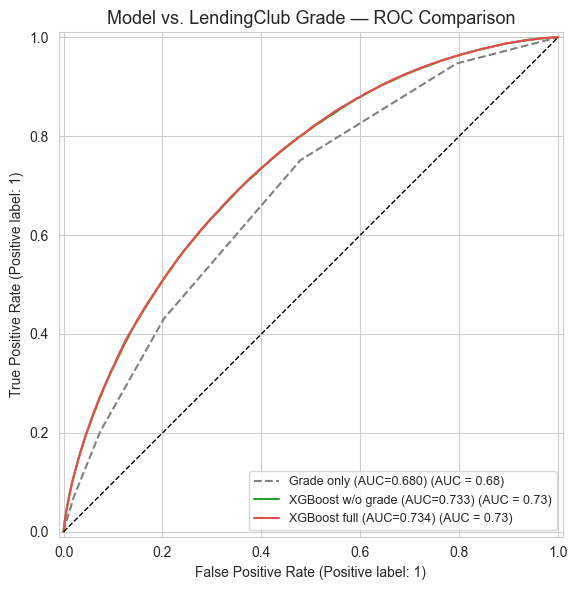


Actual default rate by grade (test set):
grade
1     6.05%
2    13.38%
3    22.46%
4    30.65%
5    38.21%
6    45.06%
7    49.24%


In [25]:
# Visual comparison
fig, ax = plt.subplots(figsize=(10, 6))

RocCurveDisplay.from_predictions(
    y_test, X_test['grade'],
    name=f'Grade only (AUC={grade_auc:.3f})',
    color='grey', linestyle='--', ax=ax
)
RocCurveDisplay.from_predictions(
    y_test, nograde_proba,
    name=f'XGBoost w/o grade (AUC={nograde_auc:.3f})',
    color='#2CA02C', ax=ax
)
RocCurveDisplay.from_predictions(
    y_test, xgb_results['proba'],
    name=f'XGBoost full (AUC={xgb_results["roc"]:.3f})',
    color='#E84C4C', ax=ax
)

ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_title('Model vs. LendingClub Grade — ROC Comparison', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Default rate by grade bucket for visual calibration check
grade_check = pd.DataFrame({'grade': X_test['grade'], 'target': y_test.values})
grade_dr = grade_check.groupby('grade')['target'].mean().sort_index()
print("\nActual default rate by grade (test set):")
print(grade_dr.apply(lambda x: f"{x:.2%}").to_string())

## 13. SHAP Top Features — Table

In [26]:
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=shap_sample.columns
).sort_values(ascending=False)

print("Top 25 features by mean |SHAP| (XGBoost):")
print(mean_shap.head(25).apply(lambda x: f"{x:.5f}").to_string())

Top 25 features by mean |SHAP| (XGBoost):
sub_grade                     0.29536
term                          0.18522
grade                         0.17439
dti                           0.12945
loan_to_income                0.10915
acc_open_past_24mths          0.10061
int_rate                      0.08072
home_ownership_RENT           0.05516
fico_range_low                0.05503
mort_acc                      0.05193
mths_since_recent_inq         0.04910
total_bc_limit                0.04727
num_actv_rev_tl               0.04513
mo_sin_old_rev_tl_op          0.04261
home_ownership_MORTGAGE       0.04257
delinq_2yrs                   0.04235
emp_length                    0.04118
mths_since_recent_bc          0.03950
loan_amnt                     0.03939
avg_cur_bal                   0.03768
credit_age_months             0.03256
annual_inc                    0.03156
total_il_high_credit_limit    0.03147
bc_util                       0.03035
total_acc                     0.02870
